In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
cards_orig = pd.read_csv('data/cards_cleaned.csv')
cards_orig.head()

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate
0,Knight,26000000,both,3.0,common,202.0,1766.0,troop,ground,ground,single,False,8.88,51.79
1,Archers,26000001,evo,3.0,common,214.0,304.0,troop,ground,both,single,True,1.44,46.10
2,Goblins,26000002,hero,2.0,common,360.0,202.0,troop,ground,ground,single,True,3.60,54.32
3,Giant,26000003,hero,5.0,rare,254.0,4090.0,troop,ground,buildings,single,False,2.32,59.10
4,P.E.K.K.A,26000004,evo,7.0,epic,816.0,3760.0,troop,ground,ground,single,False,3.28,50.61


In [11]:
# Investigating missing values

cards_orig.isnull().sum()
cards_orig.loc[cards['hitpoints11'].isnull()]
cards_orig.loc[cards['type']  == 'spell']

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate
98,Fireball,28000000,normal,4.0,rare,242.0,NaN,spell,flying,both,splash,False,18.64,53.21
99,Arrows,28000001,normal,3.0,common,294.0,NaN,spell,flying,both,splash,False,30.64,55.97
100,Rage,28000002,normal,2.0,epic,179.0,NaN,spell,ground,both,splash,False,8.48,55.06
101,Rocket,28000003,normal,6.0,rare,1484.0,NaN,spell,ground,both,splash,False,7.44,48.96
102,Goblin Barrel,28000004,evo,3.0,epic,360.0,NaN,spell,ground,both,splash,False,10.80,48.82
103,Freeze,28000005,normal,4.0,epic,41.0,NaN,spell,ground,both,splash,False,3.12,54.81
104,Lightning,28000007,normal,6.0,epic,1056.0,NaN,spell,ground,both,splash,False,7.04,56.03
105,Zap,28000008,evo,2.0,common,192.0,NaN,spell,ground,both,splash,False,11.36,52.82
106,Poison,28000009,normal,4.0,epic,256.0,NaN,spell,ground,both,splash,False,7.44,52.33
107,Graveyard,28000010,normal,5.0,legendary,1296.0,NaN,spell,ground,both,splash,False,3.44,56.34


In [12]:
cards_orig['rarity'].value_counts()
cards_orig['type'].value_counts()
cards_orig['mobility'].value_counts()
cards_orig['targets'].value_counts()
cards_orig['attack_type'].value_counts()
cards_orig['groupCard'].value_counts()
cards_orig['wild'].value_counts()

wild
normal    72
evo       37
hero       8
both       3
Name: count, dtype: int64

In [13]:
# Creating dummy variables
cards = cards_orig.copy()

cards['rarity'] = cards['rarity'].replace(
    'common', 0
).replace(
    'rare', 1
).replace(
    'epic', 2
).replace(
    'legendary', 3
).replace(
    'champion', 4
)
cards = pd.get_dummies(cards,
                       columns = ['wild', 'type', 'mobility', 'targets', 'attack_type', 'groupCard'],
                       dtype = int).drop(columns = 
    ['wild_normal', 'groupCard_False', 'attack_type_single', 'targets_ground', 'mobility_ground', 'type_troop']
)
cards.head()

C:\Users\viole\AppData\Local\Temp\ipykernel_46492\224726518.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace(


,name,id,elixirCost,rarity,damage11,hitpoints11,usage,Win Rate,wild_both,wild_evo,wild_hero,type_building,type_spell,mobility_flying,targets_both,targets_buildings,attack_type_splash,groupCard_True
0,Knight,26000000,3.0,0,202.0,1766.0,8.88,51.79,1,0,0,0,0,0,0,0,0,0
1,Archers,26000001,3.0,0,214.0,304.0,1.44,46.10,0,1,0,0,0,0,1,0,0,1
2,Goblins,26000002,2.0,0,360.0,202.0,3.60,54.32,0,0,1,0,0,0,0,0,0,1
3,Giant,26000003,5.0,1,254.0,4090.0,2.32,59.10,0,0,1,0,0,0,0,1,0,0
4,P.E.K.K.A,26000004,7.0,2,816.0,3760.0,3.28,50.61,0,1,0,0,0,0,0,0,0,0


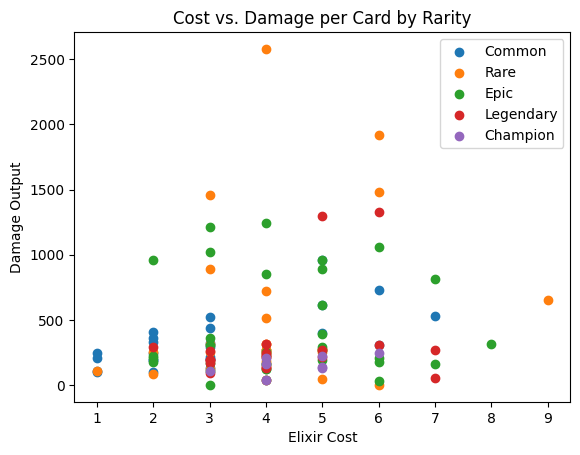

In [14]:
# Graphing bivariate relationships

rarities = ['Common', 'Rare', 'Epic', 'Legendary', 'Champion']
for i in np.arange(5):
    plt.scatter(x = cards.loc[cards['rarity'] == i]['elixirCost'],
                y = cards.loc[cards['rarity'] == i]['damage11'],
                label = rarities[i])
plt.title('Cost vs. Damage per Card by Rarity')
plt.xlabel('Elixir Cost')
plt.ylabel('Damage Output')
plt.legend()
plt.show()

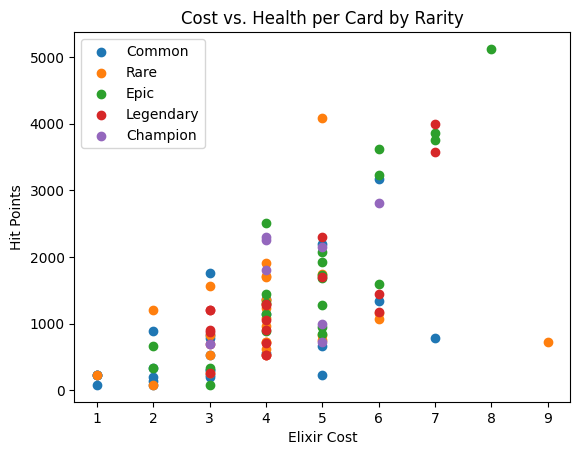

In [15]:
for i in np.arange(5):
    plt.scatter(x = cards.loc[cards['rarity'] == i]['elixirCost'],
                y = cards.loc[cards['rarity'] == i]['hitpoints11'],
                label = rarities[i])
plt.title('Cost vs. Health per Card by Rarity')
plt.xlabel('Elixir Cost')
plt.ylabel('Hit Points')
plt.legend()
plt.show()

In [32]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV, LassoCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

In [26]:
# Use median as threshold
threshold = cards['Win Rate'].median()
cards['is_high_win'] = (cards['Win Rate'] > threshold).astype(int)

print(f"\nClass distribution using median threshold ({threshold:.3f}):")
print(cards['is_high_win'].value_counts())

# Target is already created
y = cards['is_high_win']

# Features
X = cards[['elixirCost', 'damage11', 'hitpoints11', 'usage', 
           'wild_both', 'wild_evo', 'wild_hero', 
           'type_building', 'type_spell', 
           'mobility_flying', 
           'targets_both', 'targets_buildings', 
           'attack_type_splash', 
           'groupCard_True']]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale numerical columns
numerical_cols = ['elixirCost', 'damage11', 'hitpoints11', 'usage']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Fit logistic regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0],
    'odds_ratio': np.exp(log_reg.coef_[0])
})
coefficients = coefficients.sort_values('odds_ratio', ascending=False)


Class distribution using median threshold (53.435):
is_high_win
0    51
1    51
Name: count, dtype: int64
Accuracy: 0.645
ROC-AUC: 0.637

Confusion Matrix:
[[10  8]
 [ 3 10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.56      0.65        18
           1       0.56      0.77      0.65        13

    accuracy                           0.65        31
   macro avg       0.66      0.66      0.65        31
weighted avg       0.68      0.65      0.65        31



In [ ]:
# Use original y (continuous win rate), not y_sig
model1 = RidgeCV(alphas=[0.01, 0.1, 0.5, 1.0, 2.0, 2.25, 2.5, 2.75, 3.0, 3.5, 4.0, 5.0, 7.5, 10.0, 20.0, 30.0, 50.0])
model1.fit(X_train_scaled, y_train)  # Use y_train, not y_sig

print(f"Best alpha: {model1.alpha_}")
print("Coefficients:")
print(model1.coef_)

# Optional
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model1.coef_
})
print("\nTop 3 features increasing win rate:")
print(coef_df.sort_values('coefficient', ascending=False).head(3))
print("\nTop 3 features decreasing win rate:")
print(coef_df.sort_values('coefficient', ascending=True).head(3))

Best alpha: 5.0
Coefficients:
[ 0.00457777 -0.04195109 -0.13328577  0.0324313  -0.14291925 -0.2061386
  0.05320538 -0.20514503  0.          0.17228263 -0.25048358 -0.01920355
 -0.02493612 -0.01680607]

Top 3 features increasing win rate:
           feature  coefficient
9  mobility_flying     0.172283
6        wild_hero     0.053205
3            usage     0.032431

Top 3 features decreasing win rate:
          feature  coefficient
10   targets_both    -0.250484
5        wild_evo    -0.206139
7   type_building    -0.205145


In [ ]:
model2 = LassoCV(alphas=[0.01, 0.025, 0.05, 0.075, 0.1, 0.5, 1.0, 10.0], random_state=42)
model2.fit(X_train_scaled, y_train)  # Use scaled features and original y_train

print(f"Best alpha: {model2.alpha_}")
print("Coefficients:")
print(model2.coef_)

# See which features survive (non-zero coefficients)
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model2.coef_
})
non_zero = coef_df[coef_df['coefficient'] != 0]
print(f"\nFeatures selected by Lasso: {len(non_zero)} out of {len(coef_df)}")
print(non_zero.sort_values('coefficient', ascending=False))

Best alpha: 0.01
Coefficients:
[-0.         -0.03364794 -0.13788568  0.02231024 -0.10527758 -0.23650205
  0.         -0.24338621  0.          0.22313045 -0.31655243 -0.
 -0.         -0.        ]

Features selected by Lasso: 8 out of 14
            feature  coefficient
9   mobility_flying     0.223130
3             usage     0.022310
1          damage11    -0.033648
4         wild_both    -0.105278
2       hitpoints11    -0.137886
5          wild_evo    -0.236502
7     type_building    -0.243386
10     targets_both    -0.316552


In [30]:
# Predict using scaled test data (same scaler used for training)
y_pred1 = model1.predict(X_test_scaled)
y_pred2 = model2.predict(X_test_scaled)

# Compare predictions to actual
from sklearn.metrics import mean_squared_error, r2_score

print("Ridge Regression:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred1)):.3f}")
print(f"  R²: {r2_score(y_test, y_pred1):.3f}")

print("\nLasso Regression:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred2)):.3f}")
print(f"  R²: {r2_score(y_test, y_pred2):.3f}")

Ridge Regression:
  RMSE: 0.493
  R²: 0.001

Lasso Regression:
  RMSE: 0.485
  R²: 0.035


In [31]:
print(f"Ridge mean error: {np.mean(y_pred1 - y_test):.5f}")
print(f"Lasso mean error: {np.mean(y_pred2 - y_test):.5f}")

Ridge mean error: 0.08505
Lasso mean error: 0.07027


In [ ]:
# Scale all numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)  # X_train has all your features

In [36]:
# Use l1_ratio=0 for L2 penalty (same as penalty='l2')
model1 = LogisticRegression(l1_ratio=0, random_state=42)
model1.fit(X_scaled, y_train)

# Cross-validation with proper scoring
scores = cross_val_score(model1, X_scaled, y_train, scoring='accuracy', cv=5)
print(f"Cross-validation accuracy: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")

# Or ROC-AUC
auc_scores = cross_val_score(model1, X_scaled, y_train, scoring='roc_auc', cv=5)
print(f"Cross-validation ROC-AUC: {auc_scores.mean():.3f} (+/- {auc_scores.std()*2:.3f})")

Cross-validation accuracy: 0.617 (+/- 0.204)
Cross-validation ROC-AUC: 0.682 (+/- 0.089)
